In [1]:
import requests

API_KEY = "82378787c4a8d15133fd63519993cd75"

url = "https://api.fortyguard.com/v1/heatmap"

headers = {
    "api-key": API_KEY,
    "Content-Type": "application/json"
}

payload = {
    "polygon_aoi": {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {},
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [[
                        [-74.0170, 40.7050],
                        [-74.0030, 40.7050],
                        [-74.0030, 40.7180],
                        [-74.0170, 40.7180],
                        [-74.0170, 40.7050]
                    ]]
                }
            }
        ]
    },
    "date_time": {
        "start_date": "2026-08-24",
        "start_time": "14:00",
        "filter_type": 1
    },
    "granularity": 100
}

response = requests.post(url, headers=headers, json=payload)

print(response.status_code)
print(response.json())

200
{'error': False, 'status_code': 200, 'message': 'Heatmap Submitted Successfully', 'data': {'activity_id': 'c3ff2894-569f-4ab4-9dbb-f133295651a5'}}


In [2]:
import requests
import time

API_KEY = "82378787c4a8d15133fd63519993cd75"
activity_id = "8db08b69-c496-4224-8ad8-f504cf97bce5"

url = f"https://api.fortyguard.com/v1/status/{activity_id}"

headers = {
    "api-key": API_KEY
}

while True:

    response = requests.get(url, headers=headers)

    data = response.json()

    print(data)

    status = data["data"]["status"]

    if status == "Completed":
        print("DONE!")
        break

    elif status == "Failed":
        print("FAILED!")
        break

    time.sleep(5)

{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Processing'}}
{'error': False, 'status_code': 200, 'message': 'Processing', 'data': {'activity_id': '8db08b6

In [3]:
result = data["data"]

print(result.keys())

dict_keys(['activity_id', 'status', 'result'])


In [4]:
print(result)

{'activity_id': '8db08b69-c496-4224-8ad8-f504cf97bce5', 'status': 'Completed', 'result': {'map_data': {'type': 'FeatureCollection', 'features': [{'id': '0', 'type': 'Feature', 'properties': {'tile_id': 0, 'average_temperature': 27.9545, 'min_temperature': 27.9545, 'max_temperature': 27.9545}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-74.01648419268754, 40.70661795204835], [-74.01529861633273, 40.70660784449386], [-74.01528562085194, 40.70749004677328], [-74.0164712128471, 40.707500154640485], [-74.01648419268754, 40.70661795204835]]]}}, {'id': '1', 'type': 'Feature', 'properties': {'tile_id': 1, 'average_temperature': 27.9439, 'min_temperature': 27.9439, 'max_temperature': 27.9439}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-74.01529861633273, 40.70660784449386], [-74.01411304057987, 40.70659772476584], [-74.01410002945876, 40.70747992673216], [-74.01528562085194, 40.70749004677328], [-74.01529861633273, 40.70660784449386]]]}}, {'id': '2', 'type': 'Feature', 'propertie

In [5]:
import json

with open("fortyguard_result.json", "w") as f:
    json.dump(data, f, indent=4)

print("Saved!")

Saved!


In [6]:
print(data["data"].keys())

dict_keys(['activity_id', 'status', 'result'])


In [7]:
result = data["data"]["result"]

print(result.keys())

dict_keys(['map_data', 'stats_data'])


In [8]:
print(result["map_data"].keys())
print(result["stats_data"].keys())

dict_keys(['type', 'features'])
dict_keys(['temperature_stats', 'overall_temperature_distribution', 'normal_temperature_distribution', 'temperature_frequency'])


In [9]:
print(result["stats_data"]["temperature_stats"])

{'minimum': 27.9432, 'maximum': 28.4731, 'mean': 28.098613999999998, 'standard_deviation': 0.17514927402631816}


In [10]:
print(result["stats_data"]["temperature_frequency"])

{'x_axis': [28.0], 'y_axis': [150]}


In [11]:
print(len(result["map_data"]["features"]))

150


### 1. IMPORTS

In [16]:
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt
import json

API_KEY = "82378787c4a8d15133fd63519993cd75"

HEADERS = {
    "api-key": API_KEY,
    "Content-Type": "application/json"
}

# Current activity ID you already created
ACTIVITY_ID = "8db08b69-c496-4224-8ad8-f504cf97bce5"

print("Setup complete")

Setup complete


### 2. GET EXISTING HEATMAP RESULT

In [17]:
url = f"https://api.fortyguard.com/v1/status/{ACTIVITY_ID}"

response = requests.get(
    url,
    headers=HEADERS,
    timeout=60
)

data = response.json()

print("Status:", response.status_code)
print(json.dumps(data, indent=2)[:5000])

Status: 200
{
  "error": false,
  "status_code": 200,
  "message": "Completed",
  "data": {
    "activity_id": "8db08b69-c496-4224-8ad8-f504cf97bce5",
    "status": "Completed",
    "result": {
      "map_data": {
        "type": "FeatureCollection",
        "features": [
          {
            "id": "0",
            "type": "Feature",
            "properties": {
              "tile_id": 0,
              "average_temperature": 27.9545,
              "min_temperature": 27.9545,
              "max_temperature": 27.9545
            },
            "geometry": {
              "type": "Polygon",
              "coordinates": [
                [
                  [
                    -74.01648419268754,
                    40.70661795204835
                  ],
                  [
                    -74.01529861633273,
                    40.70660784449386
                  ],
                  [
                    -74.01528562085194,
                    40.70749004677328
                 

### 3. EXTRACT RESULT

In [ ]:
result = data["data"]["result"]

map_data = result["map_data"]
stats_data = result["stats_data"]

stats = stats_data["temperature_stats"]

print("Minimum:", stats["minimum"])
print("Maximum:", stats["maximum"])
print("Mean:", stats["mean"])
print("Standard Deviation:", stats["standard_deviation"])

print("Number of heatmap features:",
      len(map_data["features"]))

Minimum: 27.9432
Maximum: 28.4731
Mean: 28.098613999999998
Standard Deviation: 0.17514927402631816
Number of heatmap features: 150


### 4. HEAT RISK SCORE

In [19]:
minimum = stats["minimum"]
maximum = stats["maximum"]
mean = stats["mean"]

# Simple normalized risk score
risk_score = ((mean - 20) / (45 - 20)) * 100

risk_score = max(0, min(100, risk_score))

print(f"Average Temperature: {mean:.2f} °C")
print(f"Heat Risk Score: {risk_score:.2f}/100")

if risk_score >= 70:
    risk_level = "HIGH"
elif risk_score >= 45:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print("Risk Level:", risk_level)

Average Temperature: 28.10 °C
Heat Risk Score: 32.39/100
Risk Level: LOW


### 5. Create DataFrame

In [20]:
df = pd.DataFrame([{
    "Location": "Test Area",
    "Minimum_Temp": minimum,
    "Maximum_Temp": maximum,
    "Average_Temp": mean,
    "Std_Deviation": stats["standard_deviation"],
    "Risk_Score": risk_score,
    "Risk_Level": risk_level
}])

print(df)

    Location  Minimum_Temp  Maximum_Temp  Average_Temp  Std_Deviation  \
0  Test Area       27.9432       28.4731     28.098614       0.175149   

   Risk_Score Risk_Level  
0   32.394456        LOW  


### 6. TEMPERATURE VISUALIZATION

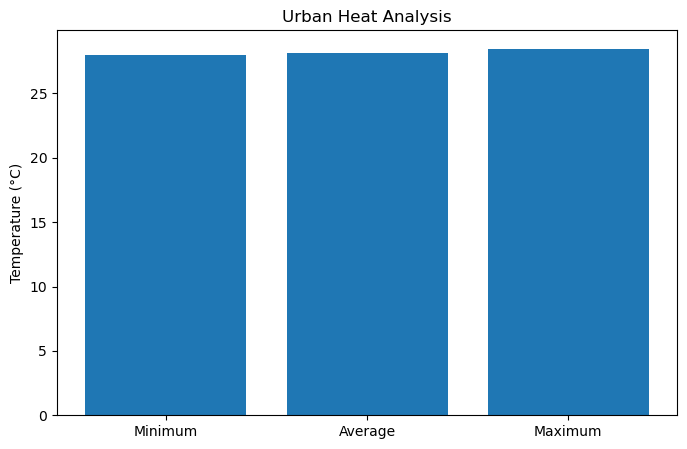

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Minimum", "Average", "Maximum"],
    [minimum, mean, maximum]
)

plt.ylabel("Temperature (°C)")
plt.title("Urban Heat Analysis")

plt.show()

### 7. Save the Data



In [22]:
df.to_csv("fortyguard_heat_analysis.csv", index=False)

print("Data saved successfully!")

Data saved successfully!


In [23]:
features = result["map_data"]["features"]

print("Total points:", len(features))

print(features[0])

Total points: 150
{'id': '0', 'type': 'Feature', 'properties': {'tile_id': 0, 'average_temperature': 27.9545, 'min_temperature': 27.9545, 'max_temperature': 27.9545}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-74.01648419268754, 40.70661795204835], [-74.01529861633273, 40.70660784449386], [-74.01528562085194, 40.70749004677328], [-74.0164712128471, 40.707500154640485], [-74.01648419268754, 40.70661795204835]]]}}


In [24]:
print(json.dumps(features[0], indent=2))

{
  "id": "0",
  "type": "Feature",
  "properties": {
    "tile_id": 0,
    "average_temperature": 27.9545,
    "min_temperature": 27.9545,
    "max_temperature": 27.9545
  },
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          -74.01648419268754,
          40.70661795204835
        ],
        [
          -74.01529861633273,
          40.70660784449386
        ],
        [
          -74.01528562085194,
          40.70749004677328
        ],
        [
          -74.0164712128471,
          40.707500154640485
        ],
        [
          -74.01648419268754,
          40.70661795204835
        ]
      ]
    ]
  }
}
